# ViGround-Contrast — LocateAnything-3B Base Model Benchmark

Notebook Kaggle hoàn chỉnh để benchmark trực tiếp trên Hugging Face dataset:

- Dataset: `thanhhoangnvbg/viground-contrast-data`
- Annotation: tự phát hiện `benchmark/standard.jsonl` và `benchmark/hard_pairs.jsonl`
- Ảnh: tải `images.zip` trực tiếp từ cùng Hugging Face dataset
- Model: `nvidia/LocateAnything-3B`
- Inference: worker chính thức, `generation_mode="hybrid"`
- Metrics: Acc@IoU 0.5/0.75, mIoU, Vietnamese Grounding Gap, Pair Accuracy, Wrong-Instance và Same-Box Collapse

## Cấu hình Kaggle

1. **Settings → Accelerator → GPU**
2. **Settings → Internet → On**
3. Không cần Add Input COCO.
4. Model và dataset đều public, không cần HF token.

## Cách chạy

Kaggle preload Transformers 5.x, trong khi LocateAnything yêu cầu `transformers==4.57.1`.

1. Bấm **Run All lần đầu**.
2. Cell cài đặt sẽ cài đúng phiên bản và restart kernel.
3. Khi Kaggle kết nối lại, bấm **Run All lần hai**.
4. Benchmark sẽ chạy từ đầu đến cuối.

> Restart chỉ xảy ra một lần trên mỗi session Kaggle mới.

## 0. Cài dependency và restart kernel

Không monkey patch. Kernel phải được restart sau khi hạ Transformers từ 5.x xuống 4.57.1.

In [ ]:
import importlib.metadata as md
import os
import subprocess
import sys
import time

TARGET_TRANSFORMERS = "4.57.1"


def package_version(name):
    try:
        return md.version(name)
    except md.PackageNotFoundError:
        return None


installed_before = package_version("transformers")
loaded_before = getattr(
    sys.modules.get("transformers"),
    "__version__",
    None,
)

print("Transformers installed on disk:", installed_before)
print("Transformers loaded in RAM:", loaded_before)

needs_install = installed_before != TARGET_TRANSFORMERS
needs_restart = (
    needs_install
    or (
        loaded_before is not None
        and loaded_before != TARGET_TRANSFORMERS
    )
)

if needs_install:
    packages = [
        f"transformers=={TARGET_TRANSFORMERS}",
        "accelerate>=1.2.0",
        "huggingface_hub>=0.34.0,<1.0",
        "Pillow==11.1.0",
        "opencv-python-headless==4.11.0.86",
        "peft>=0.13.0",
        "safetensors>=0.4.3",
        "decord==0.6.0",
        "lmdb==1.7.5",
        "tqdm>=4.66",
        "pandas>=2.0",
        "matplotlib>=3.7",
    ]

    print(
        f"\nInstalling transformers=={TARGET_TRANSFORMERS} "
        "and LocateAnything dependencies..."
    )

    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--upgrade",
            "--no-cache-dir",
            *packages,
        ]
    )

installed_after = package_version("transformers")

if installed_after != TARGET_TRANSFORMERS:
    raise RuntimeError(
        f"Expected transformers {TARGET_TRANSFORMERS}, "
        f"got {installed_after}"
    )

if needs_restart:
    print(
        "\nInstallation complete.\n"
        "Kaggle kernel is restarting now.\n"
        "After it reconnects, press Run All one more time."
    )
    time.sleep(2)
    os._exit(0)

print(
    f"Environment ready: transformers=={TARGET_TRANSFORMERS}"
)

Transformers installed on disk: 5.0.0
Transformers loaded in RAM: None

Installing transformers==4.57.1 and LocateAnything dependencies...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.7/58.7 kB 21.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 41.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 217.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 228.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 247.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 244.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.4/299.4 kB 329.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 206.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
ydata-profiling 4.18.4 requires matplotlib<=3.10,>=3.5, but you have matplotlib 3.11.0 which is incompatible.
ydata-profiling 4.18.4 requires numba<0.63,>=0.60, but you have numba 0.65.1 which is incompatible.
ydata-profiling 4.18.4 requires numpy<2.4,>=1.22, but you have numpy 2.4.6 which is incompatible.
ydata-profiling 4.18.4 requires pandas!=1.4.0,<3.0,>1.5, but you have pandas 3.0.3 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 


Installation complete.
Kaggle kernel is restarting now.
After it reconnects, press Run All one more time.


## 1. Imports, seed và GPU

In [1]:
import gc
import json
import os
import random
import re
import shutil
import time
import zipfile
from collections import defaultdict
from pathlib import Path
from statistics import mean

import numpy as np
import pandas as pd
import torch
import transformers
from PIL import Image
from tqdm.auto import tqdm

os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault(
    "PYTORCH_CUDA_ALLOC_CONF",
    "expandable_segments:True",
)

if transformers.__version__ != "4.57.1":
    raise RuntimeError(
        f"Transformers {transformers.__version__} is still "
        "loaded in RAM. Restart the Kaggle session and Run All."
    )

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is unavailable. Enable GPU in Kaggle Settings."
    )

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

props = torch.cuda.get_device_properties(0)
capability = torch.cuda.get_device_capability(0)
vram_gb = props.total_memory / 1024**3

# T4 = SM 7.5, nên dùng FP16.
# Ampere/Lovelace/Hopper/Blackwell dùng BF16.
DTYPE = (
    torch.bfloat16
    if capability[0] >= 8
    else torch.float16
)

print("GPU:", props.name)
print("Compute capability:", capability)
print(f"VRAM: {vram_gb:.1f} GB")
print("dtype:", DTYPE)
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)

GPU: Tesla T4
Compute capability: (7, 5)
VRAM: 14.6 GB
dtype: torch.float16
PyTorch: 2.10.0+cu128
Transformers: 4.57.1


## 2. Configuration

In [2]:
HF_DATASET_ID = "thanhhoangnvbg/viground-contrast-data"
DATASET_REVISION = "main"

MODEL_ID = "nvidia/LocateAnything-3B"
MODEL_REVISION = (
    "c32291ca5e996f5a7a485845b4f57a233936bba0"
)

WORK_DIR = Path("/kaggle/working/viground_base_test")
DATA_DIR = WORK_DIR / "dataset"
EXTRACT_DIR = DATA_DIR / "images_extracted"
MODEL_DIR = WORK_DIR / "LocateAnything-3B"
OUTPUT_DIR = WORK_DIR / "outputs"

for directory in (
    WORK_DIR,
    DATA_DIR,
    EXTRACT_DIR,
    MODEL_DIR,
    OUTPUT_DIR,
):
    directory.mkdir(parents=True, exist_ok=True)

GENERATION_MODE = "hybrid"

# Worker chính thức mặc định 2048.
# Single grounding thường kết thúc sớm hơn nhiều.
MAX_NEW_TOKENS = 2048

# Benchmark deterministic.
DO_SAMPLE = False

# Smoke: 15 expression, mỗi expression chạy EN + VI.
SMOKE_BILINGUAL_PAIRS = 15

# Pilot: cùng 200 expression cho EN và VI.
PILOT_BILINGUAL_PAIRS = 200

# 200 hard pairs, tối đa 400 requests trước dedup.
PILOT_HARD_PAIRS = 200

# Khi True, prediction lỗi ở checkpoint cũ sẽ được chạy lại.
RETRY_ERRORS = True

print("Dataset:", HF_DATASET_ID)
print("Model:", MODEL_ID)
print("Work dir:", WORK_DIR)
print("Output dir:", OUTPUT_DIR)

Dataset: thanhhoangnvbg/viground-contrast-data
Model: nvidia/LocateAnything-3B
Work dir: /kaggle/working/viground_base_test
Output dir: /kaggle/working/viground_base_test/outputs


## 3. HF authentication tùy chọn

Repo hiện là public nên không cần token. Nếu sau này chuyển private, thêm secret `HF_TOKEN` trong Kaggle Secrets.

In [3]:
HF_TOKEN = None

try:
    from kaggle_secrets import UserSecretsClient

    try:
        HF_TOKEN = (
            UserSecretsClient().get_secret("HF_TOKEN")
        )
    except Exception:
        HF_TOKEN = None
except Exception:
    HF_TOKEN = os.environ.get("HF_TOKEN")

if HF_TOKEN:
    from huggingface_hub import login

    login(
        token=HF_TOKEN,
        add_to_git_credential=False,
    )
    print("HF authentication enabled from Kaggle Secret")
else:
    print("Public repositories: HF token is not required")

Public repositories: HF token is not required


## 4. Phát hiện file trong Hugging Face dataset

Không hard-code cấu trúc cũ `data/benchmark/...`. Notebook đọc danh sách file thật trên Hub rồi tự tìm:

- `benchmark/standard.jsonl`
- `benchmark/hard_pairs.jsonl`
- `images.zip`

In [4]:
from huggingface_hub import HfApi

api = HfApi(token=HF_TOKEN)

dataset_info = api.dataset_info(
    repo_id=HF_DATASET_ID,
    revision=DATASET_REVISION,
)
dataset_sha = dataset_info.sha

repo_files = api.list_repo_files(
    repo_id=HF_DATASET_ID,
    repo_type="dataset",
    revision=DATASET_REVISION,
)

print("Resolved dataset revision:", dataset_sha)
print("Files in repository:", len(repo_files))


def find_unique_repo_file(
    files,
    exact_names=(),
    suffixes=(),
):
    for name in exact_names:
        if name in files:
            return name

    matches = [
        name
        for name in files
        if any(name.endswith(suffix) for suffix in suffixes)
    ]

    if len(matches) == 1:
        return matches[0]

    if not matches:
        raise FileNotFoundError(
            "No repository file matched "
            f"exact_names={exact_names}, suffixes={suffixes}"
        )

    raise RuntimeError(
        "Multiple repository files matched: "
        + ", ".join(matches)
    )


STANDARD_REPO_PATH = find_unique_repo_file(
    repo_files,
    exact_names=(
        "benchmark/standard.jsonl",
        "data/benchmark/standard.jsonl",
    ),
    suffixes=("/benchmark/standard.jsonl",),
)

HARD_PAIRS_REPO_PATH = find_unique_repo_file(
    repo_files,
    exact_names=(
        "benchmark/hard_pairs.jsonl",
        "data/benchmark/hard_pairs.jsonl",
    ),
    suffixes=("/benchmark/hard_pairs.jsonl",),
)

IMAGES_ZIP_REPO_PATH = find_unique_repo_file(
    repo_files,
    exact_names=("images.zip",),
    suffixes=("/images.zip",),
)

print("Standard benchmark:", STANDARD_REPO_PATH)
print("Hard-pair benchmark:", HARD_PAIRS_REPO_PATH)
print("Image archive:", IMAGES_ZIP_REPO_PATH)

Resolved dataset revision: eb7ddb1069de0c6e7a6277cf46b3d94d0c9cd9ee
Files in repository: 37
Standard benchmark: data/benchmark/standard.jsonl
Hard-pair benchmark: data/benchmark/hard_pairs.jsonl
Image archive: data/images.zip


## 5. Tải benchmark và `images.zip` từ Hugging Face

Không cần COCO Kaggle Input. File ảnh 902 MB được tải từ chính dataset repo.

In [5]:
from huggingface_hub import hf_hub_download

standard_path = Path(
    hf_hub_download(
        repo_id=HF_DATASET_ID,
        filename=STANDARD_REPO_PATH,
        repo_type="dataset",
        revision=dataset_sha,
        local_dir=str(DATA_DIR),
        token=HF_TOKEN,
    )
)

hard_pairs_path = Path(
    hf_hub_download(
        repo_id=HF_DATASET_ID,
        filename=HARD_PAIRS_REPO_PATH,
        repo_type="dataset",
        revision=dataset_sha,
        local_dir=str(DATA_DIR),
        token=HF_TOKEN,
    )
)

images_zip_path = Path(
    hf_hub_download(
        repo_id=HF_DATASET_ID,
        filename=IMAGES_ZIP_REPO_PATH,
        repo_type="dataset",
        revision=dataset_sha,
        local_dir=str(DATA_DIR),
        token=HF_TOKEN,
    )
)

assert standard_path.exists()
assert hard_pairs_path.exists()
assert images_zip_path.exists()

print("Standard JSONL:", standard_path)
print("Hard pairs JSONL:", hard_pairs_path)
print(
    "Images archive:",
    images_zip_path,
    f"({images_zip_path.stat().st_size / 1024**2:.1f} MB)",
)

standard.jsonl: 0.00B [00:00, ?B/s]

hard_pairs.jsonl: 0.00B [00:00, ?B/s]

data/images.zip:   0%|          | 0.00/914M [00:00<?, ?B/s]

Standard JSONL: /kaggle/working/viground_base_test/dataset/data/benchmark/standard.jsonl
Hard pairs JSONL: /kaggle/working/viground_base_test/dataset/data/benchmark/hard_pairs.jsonl
Images archive: /kaggle/working/viground_base_test/dataset/data/images.zip (871.7 MB)


## 6. Giải nén và lập chỉ mục ảnh

In [6]:
EXTRACT_MARKER = EXTRACT_DIR / ".extract_complete"
IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".webp",
    ".bmp",
}

if not EXTRACT_MARKER.exists():
    # Dọn extraction dở từ session/cell trước.
    for child in EXTRACT_DIR.iterdir():
        if child == EXTRACT_MARKER:
            continue
        if child.is_dir():
            shutil.rmtree(child)
        else:
            child.unlink()

    print("Extracting images.zip...")

    with zipfile.ZipFile(images_zip_path, "r") as archive:
        members = archive.infolist()

        for member in tqdm(
            members,
            desc="Extracting images",
        ):
            archive.extract(member, EXTRACT_DIR)

    EXTRACT_MARKER.touch()
    print("Extraction complete")
else:
    print("Extraction already complete; skipping")

image_files = [
    path
    for path in EXTRACT_DIR.rglob("*")
    if (
        path.is_file()
        and path.suffix.lower() in IMAGE_EXTENSIONS
    )
]

if not image_files:
    raise FileNotFoundError(
        f"No images found under {EXTRACT_DIR}"
    )

# Exact relative-path index.
IMAGE_RELATIVE_INDEX = {}

# Basename index can hold multiple candidates.
IMAGE_BASENAME_INDEX = defaultdict(list)

for path in image_files:
    relative = path.relative_to(EXTRACT_DIR)
    relative_key = relative.as_posix().lstrip("./")
    IMAGE_RELATIVE_INDEX[relative_key] = path
    IMAGE_BASENAME_INDEX[path.name].append(path)

print("Images extracted:", len(image_files))
print(
    "Unique basenames:",
    len(IMAGE_BASENAME_INDEX),
)
print("First files:")

for path in image_files[:5]:
    print(" -", path.relative_to(EXTRACT_DIR))

Extracting images.zip...


Extracting images:   0%|          | 0/5074 [00:00<?, ?it/s]

Extraction complete
Images extracted: 5074
Unique basenames: 5074
First files:
 - COCO_train2014_000000041771.jpg
 - COCO_train2014_000000071099.jpg
 - COCO_train2014_000000267697.jpg
 - COCO_train2014_000000505122.jpg
 - COCO_train2014_000000161818.jpg


## 7. Đọc benchmark JSONL

In [7]:
def read_jsonl(path):
    rows = []

    with open(path, "r", encoding="utf-8") as file:
        for line_number, line in enumerate(file, start=1):
            line = line.strip()

            if not line:
                continue

            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError as exc:
                raise ValueError(
                    f"Invalid JSON at {path}:{line_number}"
                ) from exc

    return rows


def write_json(path, data):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "w", encoding="utf-8") as file:
        json.dump(
            data,
            file,
            ensure_ascii=False,
            indent=2,
        )


standard_rows = read_jsonl(standard_path)
pair_rows = read_jsonl(hard_pairs_path)

en_all = [
    row
    for row in standard_rows
    if row.get("language") == "en"
]
vi_all = [
    row
    for row in standard_rows
    if row.get("language") == "vi"
]

if not en_all or not vi_all:
    raise ValueError(
        "Standard benchmark must contain both EN and VI rows"
    )

print("Standard rows:", len(standard_rows))
print("English rows:", len(en_all))
print("Vietnamese rows:", len(vi_all))
print("Hard pairs:", len(pair_rows))
print("Standard keys:", sorted(standard_rows[0].keys()))

if pair_rows:
    print("Hard-pair keys:", sorted(pair_rows[0].keys()))

Standard rows: 2000
English rows: 1000
Vietnamese rows: 1000
Hard pairs: 500
Standard keys: ['ann_id', 'bbox_xywh', 'bbox_xyxy', 'benchmark_id', 'caption_quality', 'category_id', 'category_name', 'expression_en', 'expression_vi', 'file_name', 'image_height', 'image_id', 'image_path', 'image_width', 'language', 'query', 'sample_id', 'source_dataset', 'source_split', 'split', 'translation_flags', 'translation_valid']
Hard-pair keys: ['ann_id_a', 'ann_id_b', 'benchmark_split', 'category_id', 'category_name', 'discriminative_groups', 'hard_score', 'image_id', 'pair_id', 'sample_a', 'sample_b', 'sample_id_a', 'sample_id_b', 'semantic_similarity', 'visual_distractor_score']


## 8. ID helpers, EN–VI alignment và image resolver

- Prediction ID nhất quán giữa inference và evaluation.
- EN và VI được chọn theo cùng expression gốc.
- Ảnh được resolve từ nội dung thật của `images.zip`, không phụ thuộc cấu trúc thư mục bên trong ZIP.

In [8]:
def row_id(row):
    benchmark_id = row.get("benchmark_id")

    if benchmark_id is not None:
        return str(benchmark_id)

    sample_id = row.get("sample_id")

    if sample_id is None:
        raise KeyError(
            "Row has neither benchmark_id nor sample_id: "
            f"{sorted(row.keys())}"
        )

    language = row.get("language")

    if language:
        return f"{sample_id}::{language}"

    return str(sample_id)


ALIGNMENT_KEY_CANDIDATES = (
    "sample_id",
    "source_sample_id",
    "source_id",
    "expression_id",
    "ref_id",
)


def choose_alignment_key(en_rows, vi_rows):
    best_key = None
    best_overlap = 0

    for key in ALIGNMENT_KEY_CANDIDATES:
        en_values = {
            str(row[key])
            for row in en_rows
            if row.get(key) is not None
        }
        vi_values = {
            str(row[key])
            for row in vi_rows
            if row.get(key) is not None
        }
        overlap = len(en_values & vi_values)

        if overlap > best_overlap:
            best_overlap = overlap
            best_key = key

    if best_key is None or best_overlap == 0:
        raise RuntimeError(
            "Could not align EN and VI rows. "
            f"EN keys={sorted(en_rows[0].keys())}, "
            f"VI keys={sorted(vi_rows[0].keys())}"
        )

    return best_key, best_overlap


ALIGNMENT_KEY, alignment_overlap = choose_alignment_key(
    en_all,
    vi_all,
)

en_by_alignment = {
    str(row[ALIGNMENT_KEY]): row
    for row in en_all
    if row.get(ALIGNMENT_KEY) is not None
}
vi_by_alignment = {
    str(row[ALIGNMENT_KEY]): row
    for row in vi_all
    if row.get(ALIGNMENT_KEY) is not None
}

common_alignment_keys = sorted(
    set(en_by_alignment)
    & set(vi_by_alignment)
)

if not common_alignment_keys:
    raise RuntimeError("No aligned EN–VI samples found")


def extract_pair_rows(pair):
    candidate_pairs = (
        ("sample_a", "sample_b"),
        ("a", "b"),
        ("left", "right"),
    )

    for key_a, key_b in candidate_pairs:
        a = pair.get(key_a)
        b = pair.get(key_b)

        if isinstance(a, dict) and isinstance(b, dict):
            return a, b

    raise ValueError(
        "Unsupported hard-pair schema: "
        f"{sorted(pair.keys())}"
    )


def resolve_image_path(row):
    raw_name = str(row["file_name"]).replace("\\", "/")
    normalized = raw_name.lstrip("./")

    # 1. Exact relative path.
    exact = IMAGE_RELATIVE_INDEX.get(normalized)
    if exact is not None:
        return exact

    # 2. Ignore a leading archive folder such as images/.
    parts = normalized.split("/")

    for start in range(1, len(parts)):
        suffix = "/".join(parts[start:])
        candidate = IMAGE_RELATIVE_INDEX.get(suffix)

        if candidate is not None:
            return candidate

    # 3. Unique basename fallback.
    basename = Path(normalized).name
    candidates = IMAGE_BASENAME_INDEX.get(basename, [])

    if len(candidates) == 1:
        return candidates[0]

    if not candidates:
        raise FileNotFoundError(
            f"{basename} is not present in images.zip"
        )

    raise RuntimeError(
        f"Ambiguous basename {basename}: "
        + ", ".join(
            str(path.relative_to(EXTRACT_DIR))
            for path in candidates[:10]
        )
    )


print("EN–VI alignment key:", ALIGNMENT_KEY)
print("Aligned bilingual samples:", len(common_alignment_keys))

EN–VI alignment key: sample_id
Aligned bilingual samples: 1000


## 9. Xác minh ảnh benchmark

In [9]:
probe_key = common_alignment_keys[0]
probe_rows = [
    en_by_alignment[probe_key],
    vi_by_alignment[probe_key],
]

for row in probe_rows:
    image_path = resolve_image_path(row)

    with Image.open(image_path) as image:
        print(
            row.get("language", "?").upper(),
            "|",
            image_path.relative_to(EXTRACT_DIR),
            "| size:",
            image.size,
            "| query:",
            row["query"][:100],
        )

EN | COCO_train2014_000000482326.jpg | size: (640, 448) | query: man holding phone
VI | COCO_train2014_000000482326.jpg | size: (640, 448) | query: người đàn ông cầm điện thoại


## 10. Tải snapshot model

Pin revision để benchmark tái lập và để custom code khớp với weights.

In [10]:
from huggingface_hub import snapshot_download

model_path = snapshot_download(
    repo_id=MODEL_ID,
    revision=MODEL_REVISION,
    local_dir=str(MODEL_DIR),
    token=HF_TOKEN,
)

MODEL_DIR = Path(model_path)

required_model_files = (
    "modeling_locateanything.py",
    "batch_infer.py",
)

for filename in required_model_files:
    path = MODEL_DIR / filename

    if not path.exists():
        raise FileNotFoundError(path)

print("Model snapshot:", MODEL_DIR)

Fetching 47 files:   0%|          | 0/47 [00:00<?, ?it/s]

added_tokens.json: 0.00B [00:00, ?B/s]

assets/decoding_demo.mp4:   0%|          | 0.00/25.0M [00:00<?, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

assets/coco_lvis.png:   0%|          | 0.00/235k [00:00<?, ?B/s]

...

trainer_state.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

training_args.bin:   0%|          | 0.00/7.29k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

Model snapshot: /kaggle/working/viground_base_test/LocateAnything-3B


## 11. Load LocateAnything worker

Dùng worker được NVIDIA khuyến nghị, không dùng generic Transformers pipeline.

In [11]:
from transformers import (
    AutoModel,
    AutoProcessor,
    AutoTokenizer,
)


class LocateAnythingBenchmarkWorker:
    def __init__(
        self,
        model_path,
        device="cuda",
        dtype=torch.float16,
    ):
        self.device = device
        self.dtype = dtype

        print("Loading tokenizer...")
        self.tokenizer = AutoTokenizer.from_pretrained(
            model_path,
            trust_remote_code=True,
        )

        print("Loading processor...")
        self.processor = AutoProcessor.from_pretrained(
            model_path,
            trust_remote_code=True,
        )

        print("Loading model...")
        started = time.time()

        self.model = AutoModel.from_pretrained(
            model_path,
            torch_dtype=dtype,
            trust_remote_code=True,
            low_cpu_mem_usage=True,
        ).to(device).eval()

        print(
            f"Model loaded in {time.time() - started:.1f}s"
        )
        print(
            "VRAM allocated:",
            f"{torch.cuda.memory_allocated() / 1024**3:.2f} GB",
        )
        print(
            "VRAM reserved:",
            f"{torch.cuda.memory_reserved() / 1024**3:.2f} GB",
        )

    @staticmethod
    def build_prompt(query):
        return (
            "Locate a single instance that matches the "
            f"following description: {query}."
        )

    def extract_answer(self, response):
        candidate = (
            response[0]
            if isinstance(response, tuple)
            else response
        )

        if isinstance(candidate, str):
            return candidate

        if isinstance(candidate, (list, tuple)):
            if not candidate:
                return ""

            if isinstance(candidate[0], str):
                return candidate[0]

            candidate = candidate[0]

        if torch.is_tensor(candidate):
            if candidate.ndim == 1:
                candidate = candidate.unsqueeze(0)

            decoded = self.tokenizer.batch_decode(
                candidate,
                skip_special_tokens=False,
            )
            return decoded[0]

        return str(candidate)

    @torch.inference_mode()
    def predict(self, image, query):
        image = image.convert("RGB")
        prompt = self.build_prompt(query)

        messages = [
            {
                "role": "user",
                "content": [
                    {
                        "type": "image",
                        "image": image,
                    },
                    {
                        "type": "text",
                        "text": prompt,
                    },
                ],
            }
        ]

        text = self.processor.py_apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )
        images, videos = (
            self.processor.process_vision_info(messages)
        )

        inputs = self.processor(
            text=[text],
            images=images,
            videos=videos,
            return_tensors="pt",
        ).to(self.device)

        generation_kwargs = {
            "pixel_values": inputs["pixel_values"].to(
                self.dtype
            ),
            "input_ids": inputs["input_ids"],
            "attention_mask": inputs["attention_mask"],
            "image_grid_hws": inputs.get(
                "image_grid_hws",
                None,
            ),
            "tokenizer": self.tokenizer,
            "max_new_tokens": MAX_NEW_TOKENS,
            "use_cache": True,
            "generation_mode": GENERATION_MODE,
            "do_sample": DO_SAMPLE,
            "verbose": False,
        }

        if DO_SAMPLE:
            generation_kwargs.update(
                temperature=0.7,
                top_p=0.9,
                repetition_penalty=1.1,
            )

        started = time.perf_counter()
        response = self.model.generate(
            **generation_kwargs
        )
        latency_ms = (
            time.perf_counter() - started
        ) * 1000

        answer = self.extract_answer(response)

        result = {
            "answer": answer,
            "latency_ms": latency_ms,
        }

        if (
            isinstance(response, tuple)
            and len(response) >= 3
        ):
            result["stats"] = str(response[2])

        return result


worker = LocateAnythingBenchmarkWorker(
    model_path=str(MODEL_DIR),
    device="cuda",
    dtype=DTYPE,
)

2026-06-13 14:00:50.442369: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781359250.690846     126 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781359250.765093     126 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781359251.327468     126 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781359251.327502     126 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781359251.327505     126 computation_placer.cc:177] computation placer alr

Loading tokenizer...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Loading processor...


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/image_processing_auto.py:647: FutureWarning: The image_processor_class argument is deprecated and will be removed in v4.42. Please use `slow_image_processor_class`, or `fast_image_processor_class` instead
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!


Loading model...


Qwen2ForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly defined. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Model loaded in 11.6s
VRAM allocated: 7.12 GB
VRAM reserved: 7.12 GB


## 12. Parser, IoU và checkpointed inference

Parser hỗ trợ cả output chuẩn:

```text
<box><x1><y1><x2><y2></box>
```

và biến thể:

```text
<box>x1, y1, x2, y2</box>
```

In [12]:
BOX_TOKEN_RE = re.compile(
    r"<box>\s*"
    r"<\s*(\d+(?:\.\d+)?)\s*>\s*"
    r"<\s*(\d+(?:\.\d+)?)\s*>\s*"
    r"<\s*(\d+(?:\.\d+)?)\s*>\s*"
    r"<\s*(\d+(?:\.\d+)?)\s*>\s*"
    r"</box>",
    re.IGNORECASE,
)

BOX_COMMA_RE = re.compile(
    r"<box>\s*\(?\s*"
    r"([+-]?\d+(?:\.\d+)?)\s*,\s*"
    r"([+-]?\d+(?:\.\d+)?)\s*,\s*"
    r"([+-]?\d+(?:\.\d+)?)\s*,\s*"
    r"([+-]?\d+(?:\.\d+)?)\s*"
    r"\)?\s*</box>",
    re.IGNORECASE,
)


def parse_boxes(text, image_width, image_height):
    text = text or ""
    values = []

    for regex in (BOX_TOKEN_RE, BOX_COMMA_RE):
        for match in regex.finditer(text):
            values.append(
                [
                    float(match.group(index))
                    for index in range(1, 5)
                ]
            )

    unique_values = []
    seen = set()

    for box in values:
        key = tuple(round(value, 6) for value in box)

        if key not in seen:
            seen.add(key)
            unique_values.append(box)

    normalized_boxes = []
    pixel_boxes = []

    for x1, y1, x2, y2 in unique_values:
        coordinates = (x1, y1, x2, y2)

        if x2 <= x1 or y2 <= y1:
            continue

        if any(
            value < 0 or value > 1000
            for value in coordinates
        ):
            continue

        normalized = [
            int(round(value))
            for value in coordinates
        ]

        pixel = [
            max(
                0.0,
                min(
                    x1 / 1000 * image_width,
                    float(image_width),
                ),
            ),
            max(
                0.0,
                min(
                    y1 / 1000 * image_height,
                    float(image_height),
                ),
            ),
            max(
                0.0,
                min(
                    x2 / 1000 * image_width,
                    float(image_width),
                ),
            ),
            max(
                0.0,
                min(
                    y2 / 1000 * image_height,
                    float(image_height),
                ),
            ),
        ]

        if (
            pixel[2] > pixel[0]
            and pixel[3] > pixel[1]
        ):
            normalized_boxes.append(normalized)
            pixel_boxes.append(pixel)

    return (
        normalized_boxes,
        pixel_boxes,
        bool(pixel_boxes),
    )


def iou(box_a, box_b):
    intersection_x1 = max(box_a[0], box_b[0])
    intersection_y1 = max(box_a[1], box_b[1])
    intersection_x2 = min(box_a[2], box_b[2])
    intersection_y2 = min(box_a[3], box_b[3])

    intersection = (
        max(0.0, intersection_x2 - intersection_x1)
        * max(0.0, intersection_y2 - intersection_y1)
    )

    area_a = (
        max(0.0, box_a[2] - box_a[0])
        * max(0.0, box_a[3] - box_a[1])
    )
    area_b = (
        max(0.0, box_b[2] - box_b[0])
        * max(0.0, box_b[3] - box_b[1])
    )

    union = area_a + area_b - intersection

    return intersection / union if union > 0 else 0.0


def predict_one(row):
    image_path = resolve_image_path(row)

    try:
        with Image.open(image_path) as source:
            image = source.convert("RGB")

        prediction = worker.predict(
            image=image,
            query=row.get("query") if row.get("query") is not None else (row.get("expression_vi") or row.get("expression_en")),
        )

        normalized, pixel, parse_ok = parse_boxes(
            prediction["answer"],
            image.width,
            image.height,
        )

        return {
            "raw": prediction["answer"],
            "norm": normalized,
            "pixel": pixel,
            "parse_ok": parse_ok,
            "latency_ms": prediction["latency_ms"],
            "image_width": image.width,
            "image_height": image.height,
            "error": None,
        }

    except Exception as exc:
        gc.collect()
        torch.cuda.empty_cache()

        return {
            "raw": "",
            "norm": [],
            "pixel": [],
            "parse_ok": False,
            "latency_ms": 0.0,
            "error": f"{type(exc).__name__}: {exc}",
        }


def load_predictions(path):
    path = Path(path)
    predictions = {}

    if not path.exists():
        return predictions

    with open(path, "r", encoding="utf-8") as file:
        for line in file:
            line = line.strip()

            if not line:
                continue

            record = json.loads(line)
            predictions[str(record["id"])] = (
                record["prediction"]
            )

    return predictions


def append_prediction(path, identifier, prediction):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    record = {
        "id": str(identifier),
        "prediction": prediction,
    }

    with open(path, "a", encoding="utf-8") as file:
        file.write(
            json.dumps(
                record,
                ensure_ascii=False,
            )
            + "\n"
        )


def predict_rows(rows, checkpoint_path, description):
    predictions = load_predictions(checkpoint_path)

    pending = []

    for row in rows:
        identifier = row_id(row)
        old_prediction = predictions.get(identifier)

        should_retry = (
            RETRY_ERRORS
            and old_prediction is not None
            and old_prediction.get("error")
        )

        if old_prediction is None or should_retry:
            pending.append(row)

    print(
        f"{description}: total={len(rows)}, "
        f"available={len(predictions)}, "
        f"pending={len(pending)}"
    )

    for row in tqdm(pending, desc=description):
        identifier = row_id(row)
        prediction = predict_one(row)
        predictions[identifier] = prediction
        append_prediction(
            checkpoint_path,
            identifier,
            prediction,
        )

    return predictions


print("Inference utilities ready")


Inference utilities ready


# Phase 1 — Balanced bilingual smoke test

Chọn cùng 15 expression gốc cho EN và VI, tổng 30 requests.

In [13]:
smoke_rng = random.Random(SEED)

smoke_keys = smoke_rng.sample(
    common_alignment_keys,
    min(
        SMOKE_BILINGUAL_PAIRS,
        len(common_alignment_keys),
    ),
)

smoke_en = [
    en_by_alignment[key]
    for key in smoke_keys
]
smoke_vi = [
    vi_by_alignment[key]
    for key in smoke_keys
]
smoke_rows = smoke_en + smoke_vi

smoke_checkpoint = (
    OUTPUT_DIR / "smoke_predictions.jsonl"
)

smoke_predictions = predict_rows(
    smoke_rows,
    smoke_checkpoint,
    "Smoke EN+VI",
)

parse_success = sum(
    bool(
        smoke_predictions[row_id(row)].get(
            "parse_ok"
        )
    )
    for row in smoke_rows
)

exactly_one_box = sum(
    len(
        smoke_predictions[row_id(row)].get(
            "pixel",
            [],
        )
    )
    == 1
    for row in smoke_rows
)

runtime_errors = [
    smoke_predictions[row_id(row)].get("error")
    for row in smoke_rows
    if smoke_predictions[row_id(row)].get("error")
]

print("\n" + "=" * 64)
print("BALANCED BILINGUAL SMOKE TEST")
print("=" * 64)
print("Requests:", len(smoke_rows))
print(
    "Parser success:",
    f"{parse_success}/{len(smoke_rows)}",
)
print(
    "Exactly one box:",
    f"{exactly_one_box}/{len(smoke_rows)}",
)
print("Runtime errors:", len(runtime_errors))

if runtime_errors:
    print("First error:", runtime_errors[0])

write_json(
    OUTPUT_DIR / "smoke_result.json",
    {
        "requests": len(smoke_rows),
        "parse_success": parse_success,
        "exactly_one_box": exactly_one_box,
        "runtime_errors": runtime_errors,
    },
)

Smoke EN+VI: total=30, available=0, pending=30


Smoke EN+VI:   0%|          | 0/30 [00:00<?, ?it/s]

/root/.cache/huggingface/modules/transformers_modules/LocateAnything_hyphen_3B/generate_utils.py:186: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  box_avg.append(torch.tensor(out_ref, dtype=x0.dtype, device=x0.device))



BALANCED BILINGUAL SMOKE TEST
Requests: 30
Parser success: 29/30
Exactly one box: 28/30
Runtime errors: 0


## Smoke examples

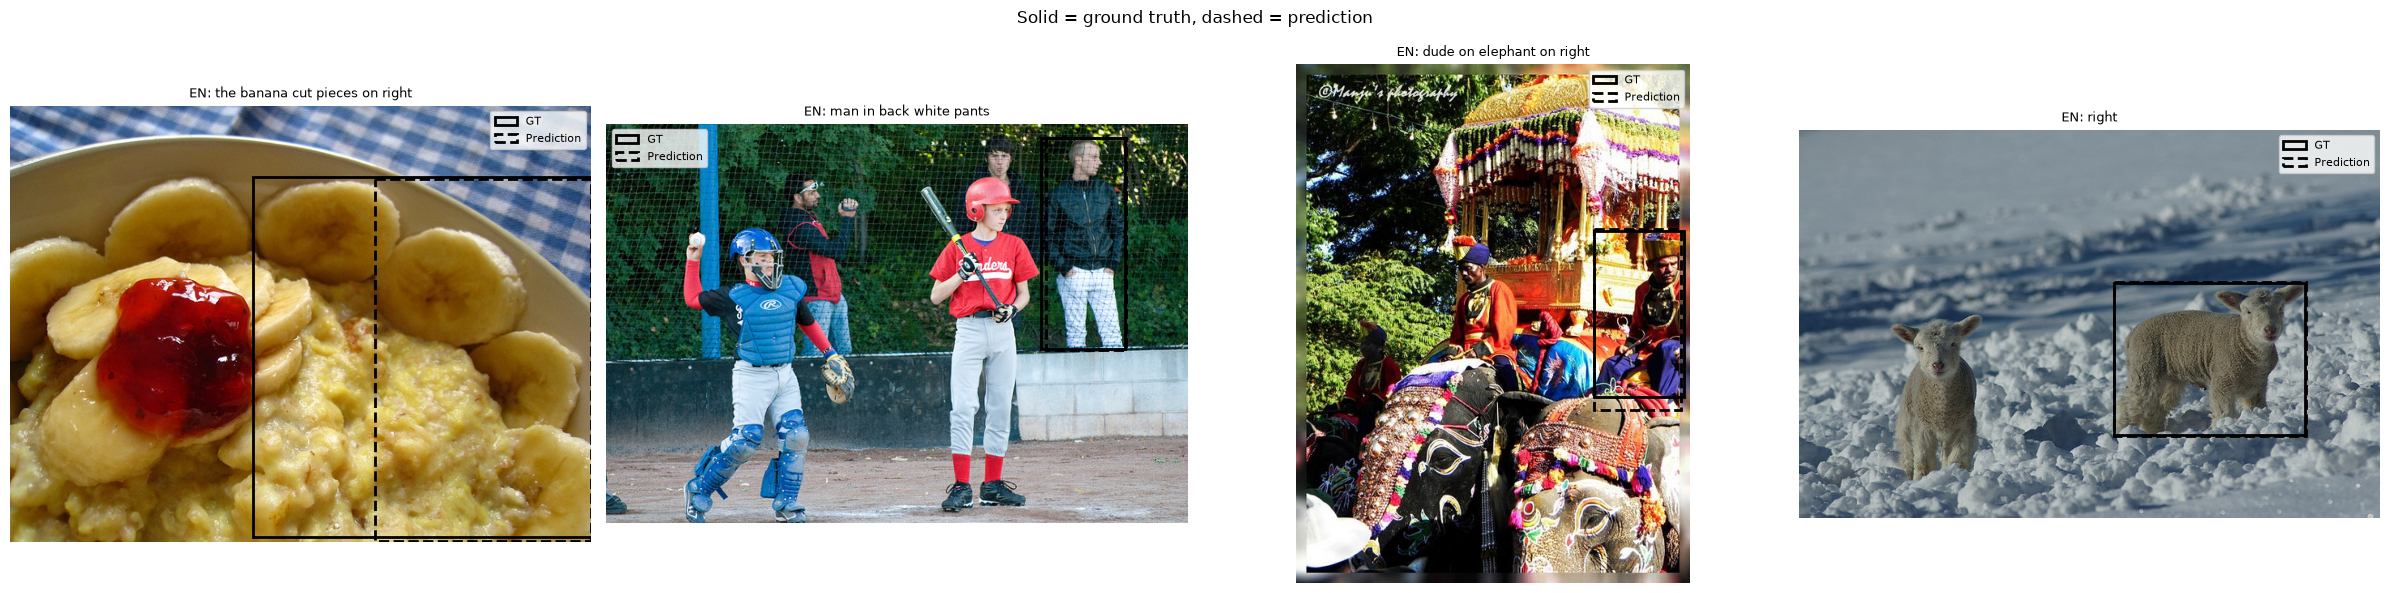

Saved: /kaggle/working/viground_base_test/outputs/smoke_examples.png


In [14]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt

examples = smoke_rows[:4]

figure, axes = plt.subplots(
    1,
    len(examples),
    figsize=(6 * len(examples), 6),
)

if len(examples) == 1:
    axes = [axes]

for axis, row in zip(axes, examples):
    identifier = row_id(row)
    prediction = smoke_predictions[identifier]
    image_path = resolve_image_path(row)

    with Image.open(image_path) as source:
        image = source.convert("RGB")

    axis.imshow(image)
    axis.set_title(
        f"{row.get('language', '?').upper()}: "
        f"{row['query'][:60]}",
        fontsize=9,
    )

    ground_truth = row["bbox_xyxy"]

    axis.add_patch(
        patches.Rectangle(
            (
                ground_truth[0],
                ground_truth[1],
            ),
            ground_truth[2] - ground_truth[0],
            ground_truth[3] - ground_truth[1],
            fill=False,
            linewidth=2,
            linestyle="-",
            label="GT",
        )
    )

    if prediction.get("pixel"):
        predicted = prediction["pixel"][0]

        axis.add_patch(
            patches.Rectangle(
                (
                    predicted[0],
                    predicted[1],
                ),
                predicted[2] - predicted[0],
                predicted[3] - predicted[1],
                fill=False,
                linewidth=2,
                linestyle="--",
                label="Prediction",
            )
        )

    axis.legend(fontsize=8)
    axis.axis("off")

plt.suptitle(
    "Solid = ground truth, dashed = prediction"
)
plt.tight_layout()

smoke_figure_path = (
    OUTPUT_DIR / "smoke_examples.png"
)
plt.savefig(
    smoke_figure_path,
    dpi=150,
    bbox_inches="tight",
)
plt.show()

print("Saved:", smoke_figure_path)

# Phase 2 — Pilot benchmark

- 200 aligned English expressions
- 200 corresponding Vietnamese expressions
- 200 hard pairs
- Prediction checkpointed after every request

In [15]:
pilot_rng = random.Random(SEED)

pilot_alignment_keys = pilot_rng.sample(
    common_alignment_keys,
    min(
        PILOT_BILINGUAL_PAIRS,
        len(common_alignment_keys),
    ),
)

en_sample = [
    en_by_alignment[key]
    for key in pilot_alignment_keys
]
vi_sample = [
    vi_by_alignment[key]
    for key in pilot_alignment_keys
]

pair_sample = pilot_rng.sample(
    pair_rows,
    min(PILOT_HARD_PAIRS, len(pair_rows)),
)

all_inference_rows = []
seen_prediction_ids = set()


def add_unique_rows(rows):
    for row in rows:
        identifier = row_id(row)

        if identifier not in seen_prediction_ids:
            seen_prediction_ids.add(identifier)
            all_inference_rows.append(row)


add_unique_rows(en_sample)
add_unique_rows(vi_sample)

for pair in pair_sample:
    sample_a, sample_b = extract_pair_rows(pair)
    add_unique_rows([sample_a, sample_b])

print("Pilot English:", len(en_sample))
print("Pilot Vietnamese:", len(vi_sample))
print("Pilot hard pairs:", len(pair_sample))
print(
    "Unique inference requests:",
    len(all_inference_rows),
)

Pilot English: 200
Pilot Vietnamese: 200
Pilot hard pairs: 200
Unique inference requests: 800


In [16]:
pilot_checkpoint = (
    OUTPUT_DIR / "pilot_predictions.jsonl"
)

started = time.time()

pilot_predictions = predict_rows(
    all_inference_rows,
    pilot_checkpoint,
    "Pilot inference",
)

elapsed = time.time() - started

pilot_ids = {
    row_id(row)
    for row in all_inference_rows
}
latencies = [
    pilot_predictions[identifier]["latency_ms"]
    for identifier in pilot_ids
    if (
        identifier in pilot_predictions
        and pilot_predictions[identifier].get(
            "latency_ms",
            0,
        )
        > 0
    )
]

print(
    f"Pilot cell elapsed: {elapsed:.1f}s"
)
print(
    "Predictions available:",
    len(
        pilot_ids
        & set(pilot_predictions.keys())
    ),
)

if latencies:
    print(
        "Mean model latency:",
        f"{mean(latencies):.1f} ms/request",
    )

Pilot inference: total=800, available=0, pending=800


Pilot inference:   0%|          | 0/800 [00:00<?, ?it/s]

Pilot cell elapsed: 1406.5s
Predictions available: 800
Mean model latency: 1739.5 ms/request


## 13. Evaluation

In [17]:
def evaluate_standard(rows, predictions):
    iou_values = []
    parse_failures = 0
    multi_box_outputs = 0
    runtime_errors = 0

    for row in rows:
        prediction = predictions.get(row_id(row))

        if (
            prediction
            and prediction.get("error")
        ):
            runtime_errors += 1

        if (
            not prediction
            or not prediction.get("parse_ok")
            or not prediction.get("pixel")
            or len(prediction["pixel"]) != 1
        ):
            parse_failures += 1
            if prediction and len(prediction.get("pixel", [])) > 1:
                multi_box_outputs += 1
            iou_values.append(0.0)
            continue

        predicted_box = prediction["pixel"][0]
        ground_truth_box = row["bbox_xyxy"]

        iou_values.append(
            iou(predicted_box, ground_truth_box)
        )

    count = len(rows)

    return {
        "n": count,
        "mIoU": (
            round(mean(iou_values), 4)
            if iou_values
            else 0.0
        ),
        "Acc@0.5": (
            round(
                sum(
                    value >= 0.5
                    for value in iou_values
                )
                / count,
                4,
            )
            if count
            else 0.0
        ),
        "Acc@0.75": (
            round(
                sum(
                    value >= 0.75
                    for value in iou_values
                )
                / count,
                4,
            )
            if count
            else 0.0
        ),
        "Parse Fail": (
            round(parse_failures / count, 4)
            if count
            else 0.0
        ),
        "Multi-box": (
            round(multi_box_outputs / count, 4)
            if count
            else 0.0
        ),
        "Runtime Error": (
            round(runtime_errors / count, 4)
            if count
            else 0.0
        ),
    }


def evaluate_hard_pairs(pairs, predictions):
    pair_correctness = []
    pair_min_ious = []
    wrong_instance_flags = []
    collapse_flags = []
    parse_failures = 0
    runtime_errors = 0
    cross_image_pairs = 0

    for pair in pairs:
        sample_a, sample_b = extract_pair_rows(pair)

        prediction_a = predictions.get(
            row_id(sample_a)
        )
        prediction_b = predictions.get(
            row_id(sample_b)
        )

        if (
            prediction_a
            and prediction_a.get("error")
        ) or (
            prediction_b
            and prediction_b.get("error")
        ):
            runtime_errors += 1

        valid = (
            prediction_a
            and prediction_b
            and prediction_a.get("parse_ok")
            and prediction_b.get("parse_ok")
            and prediction_a.get("pixel")
            and prediction_b.get("pixel")
            and len(prediction_a["pixel"]) == 1
            and len(prediction_b["pixel"]) == 1
        )

        if not valid:
            parse_failures += 1
            pair_correctness.append(False)
            pair_min_ious.append(0.0)
            wrong_instance_flags.extend(
                [False, False]
            )
            collapse_flags.append(False)
            continue

        predicted_a = prediction_a["pixel"][0]
        predicted_b = prediction_b["pixel"][0]
        ground_truth_a = sample_a["bbox_xyxy"]
        ground_truth_b = sample_b["bbox_xyxy"]

        own_iou_a = iou(
            predicted_a,
            ground_truth_a,
        )
        own_iou_b = iou(
            predicted_b,
            ground_truth_b,
        )

        pair_correctness.append(
            own_iou_a >= 0.5
            and own_iou_b >= 0.5
        )
        pair_min_ious.append(
            min(own_iou_a, own_iou_b)
        )

        same_image = (
            Path(sample_a["file_name"]).name
            == Path(sample_b["file_name"]).name
        )

        if same_image:
            wrong_instance_flags.append(
                iou(
                    predicted_a,
                    ground_truth_b,
                )
                > own_iou_a
            )
            wrong_instance_flags.append(
                iou(
                    predicted_b,
                    ground_truth_a,
                )
                > own_iou_b
            )

            collapse_flags.append(
                iou(predicted_a, predicted_b) >= 0.7
                and iou(
                    ground_truth_a,
                    ground_truth_b,
                )
                < 0.3
            )
        else:
            cross_image_pairs += 1
            wrong_instance_flags.extend(
                [False, False]
            )
            collapse_flags.append(False)

    count = len(pairs)

    return {
        "n": count,
        "Pair Accuracy": (
            round(
                sum(pair_correctness) / count,
                4,
            )
            if count
            else 0.0
        ),
        "Pair mIoU": (
            round(mean(pair_min_ious), 4)
            if pair_min_ious
            else 0.0
        ),
        "Wrong-Instance": (
            round(
                sum(wrong_instance_flags)
                / len(wrong_instance_flags),
                4,
            )
            if wrong_instance_flags
            else 0.0
        ),
        "Same-Box Collapse": (
            round(
                sum(collapse_flags) / count,
                4,
            )
            if count
            else 0.0
        ),
        "Parse Fail": (
            round(parse_failures / count, 4)
            if count
            else 0.0
        ),
        "Runtime Error": (
            round(runtime_errors / count, 4)
            if count
            else 0.0
        ),
        "Cross-image Pairs": cross_image_pairs,
    }


english_metrics = evaluate_standard(
    en_sample,
    pilot_predictions,
)
vietnamese_metrics = evaluate_standard(
    vi_sample,
    pilot_predictions,
)
hard_pair_metrics = evaluate_hard_pairs(
    pair_sample,
    pilot_predictions,
)

vietnamese_grounding_gap = round(
    english_metrics["Acc@0.5"]
    - vietnamese_metrics["Acc@0.5"],
    4,
)

print("\n" + "=" * 76)
print("LOCATEANYTHING-3B ZERO-SHOT \u2014 HF BENCHMARK")
print("=" * 76)
print("English:", english_metrics)
print("Vietnamese:", vietnamese_metrics)
print(
    "Vietnamese Grounding Gap:",
    vietnamese_grounding_gap,
)
print("Hard pairs:", hard_pair_metrics)



LOCATEANYTHING-3B ZERO-SHOT — HF BENCHMARK
English: {'n': 200, 'mIoU': 0.8371, 'Acc@0.5': 0.91, 'Acc@0.75': 0.825, 'Parse Fail': 0.04, 'Multi-box': 0.04, 'Runtime Error': 0.0}
Vietnamese: {'n': 200, 'mIoU': 0.6867, 'Acc@0.5': 0.73, 'Acc@0.75': 0.62, 'Parse Fail': 0.075, 'Multi-box': 0.065, 'Runtime Error': 0.0}
Vietnamese Grounding Gap: 0.18
Hard pairs: {'n': 200, 'Pair Accuracy': 0.52, 'Pair mIoU': 0.4948, 'Wrong-Instance': 0.125, 'Same-Box Collapse': 0.115, 'Parse Fail': 0.045, 'Runtime Error': 0.0, 'Cross-image Pairs': 0}


## 14. Results và export

In [18]:
standard_table = pd.DataFrame(
    [
        {
            "Split": "English",
            **english_metrics,
        },
        {
            "Split": "Vietnamese",
            **vietnamese_metrics,
        },
    ]
)

hard_pair_table = pd.DataFrame(
    [
        {
            "Split": "Hard Pairs",
            **hard_pair_metrics,
        }
    ]
)

display(standard_table)
display(hard_pair_table)

report = {
    "model_id": MODEL_ID,
    "model_revision": MODEL_REVISION,
    "dataset_id": HF_DATASET_ID,
    "dataset_revision": dataset_sha,
    "transformers_version": (
        transformers.__version__
    ),
    "gpu": props.name,
    "dtype": str(DTYPE),
    "generation_mode": GENERATION_MODE,
    "max_new_tokens": MAX_NEW_TOKENS,
    "do_sample": DO_SAMPLE,
    "seed": SEED,
    "english": english_metrics,
    "vietnamese": vietnamese_metrics,
    "vietnamese_grounding_gap": (
        vietnamese_grounding_gap
    ),
    "hard_pairs": hard_pair_metrics,
    "unique_inference_requests": len(
        all_inference_rows
    ),
}

report_path = OUTPUT_DIR / "pilot_result.json"
standard_csv_path = (
    OUTPUT_DIR / "standard_metrics.csv"
)
hard_pair_csv_path = (
    OUTPUT_DIR / "hard_pair_metrics.csv"
)

write_json(report_path, report)
standard_table.to_csv(
    standard_csv_path,
    index=False,
)
hard_pair_table.to_csv(
    hard_pair_csv_path,
    index=False,
)

print("Saved:", report_path)
print("Saved:", standard_csv_path)
print("Saved:", hard_pair_csv_path)

,Split,n,mIoU,Acc@0.5,Acc@0.75,Parse Fail,Multi-box,Runtime Error
0,English,200,0.8371,0.91,0.825,0.040,0.040,0.0
1,Vietnamese,200,0.6867,0.73,0.620,0.075,0.065,0.0


,Split,n,Pair Accuracy,Pair mIoU,Wrong-Instance,Same-Box Collapse,Parse Fail,Runtime Error,Cross-image Pairs
0,Hard Pairs,200,0.52,0.4948,0.125,0.115,0.045,0.0,0


Saved: /kaggle/working/viground_base_test/outputs/pilot_result.json
Saved: /kaggle/working/viground_base_test/outputs/standard_metrics.csv
Saved: /kaggle/working/viground_base_test/outputs/hard_pair_metrics.csv


In [19]:
archive_base = Path(
    "/kaggle/working/viground_base_test_results"
)

archive_path = shutil.make_archive(
    str(archive_base),
    "zip",
    root_dir=OUTPUT_DIR,
)

print("Result archive:", archive_path)
print(
    "Download it from Kaggle's Output/Files panel."
)

Result archive: /kaggle/working/viground_base_test_results.zip
Download it from Kaggle's Output/Files panel.


## 15. Giải phóng VRAM thủ công

Không chạy tự động trong Run All để worker còn sẵn sàng cho việc kiểm tra thêm.

In [ ]:
# Chỉ bỏ comment khi không cần model nữa.
#
# del worker
# gc.collect()
# torch.cuda.empty_cache()
#
# print(
#     "VRAM reserved:",
#     f"{torch.cuda.memory_reserved() / 1024**3:.2f} GB",
# )

# Ghi chú

- Notebook tải đúng `images.zip` từ `thanhhoangnvbg/viground-contrast-data`.
- Không yêu cầu Add Input COCO.
- Đường dẫn benchmark được tự phát hiện nên dùng được cả cấu trúc `benchmark/...` và cấu trúc cũ `data/benchmark/...`.
- EN và VI được đánh giá trên cùng expression gốc.
- Hard-pair inference và evaluation dùng cùng một hàm ID.
- Prediction được checkpoint sau từng request. Chạy lại sẽ resume.
- Kết quả cuối nằm tại `/kaggle/working/viground_base_test_results.zip`.
